# 06 — Resampling and Model Stability

This notebook moves the project from exploratory modeling into model validation and stability analysis.

The goal is to evaluate whether model performance is robust to:
- resampling variation
- time-aware train/test splits
- feature selection changes
- permutation-based feature sensitivity

This notebook also uses findings from prior analyses to define a cleaner final modeling dataset:
- reduced multicollinearity
- transformed heavy-tailed variables
- more stable and interpretable inputs

The central question is:

**How reliable are the modeling results once we account for resampling, temporal structure, and feature sensitivity?**

This notebook should answer:

How stable are the modeling results once we account for resampling, time-aware validation, and feature sensitivity?

And just as importantly:

Does the cleaned, transformed, reduced feature set actually improve reliability versus the original modeling dataset?

## 1. Final modeling dataset design

Build a clean, explicit final feature set using what we learned in 05:
- drop highly collinear variables
- keep one feature per signal cluster where appropriate
- transform skewed variables
- keep interpretable variables where possible

## 2. Stable modeling pipeline

Build a reusable pipeline with:
- preprocessing
- transformations
- optional scaling
- model
- evaluation

## 3. Resampling and validation

Include:
- bootstrap confidence intervals
- K-fold or repeated CV
- rolling-origin validation
- train/test window sensitivity

## 4. Robustness and interpretability

Include:
- permutation importance
- feature importance stability
- comparison across resamples

## 5. Pre vs post refinement comparison

Show whether the final feature set:
- improves performance
- improves stability
- improves interpretability


# targets 

primary: finish_position

secondary: optional target_points

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Load Final Source Data

Use the pre-race feature store as the base for the final modeling dataset. This is the cleanest starting point for validating model stability because it avoids in-race leakage and preserves interpretable pre-race structure.

In [3]:
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")

print("Pre-race:", prerace.shape)
print("Master:", master.shape)

Pre-race: (26759, 49)
Master: (26759, 103)


## Define Original vs Refined Feature Sets

Compare the earlier broad modeling set with a refined version informed by:
- skewness and kurtosis diagnostics
- multicollinearity checks
- PCA and feature redundancy analysis

In [4]:
original_features = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

In [5]:
#one feature per major cluster 
refined_features = [
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "constructor_dnf_rate_last5",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

In [6]:
df = prerace.copy()

# example transformed variables 
for col in ["temp_avg", "precipitation", "wind_speed"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

## Define targets and build working dataset


In [7]:
target = "finish_position"

model_cols_original = [target, "year"] + original_features
model_cols_refined = [target, "year"] + refined_features

df_original = df[model_cols_original].copy()
df_refined = df[model_cols_refined].copy()

for frame in [df_original, df_refined]:
    for col in frame.columns:
        frame[col] = pd.to_numeric(frame[col], errors="coerce")

In [9]:
#missingness check
pd.DataFrame({
    "original_missing_pct": df_original.isna().mean(),
    "refined_missing_pct": df_refined.isna().mean()
})

,original_missing_pct,refined_missing_pct
alt,0.000000,0.000000
constructor_avg_finish_last5,0.031503,0.031503
constructor_dnf_rate_last5,0.031503,0.031503
constructor_points_last5,0.031503,NaN
constructor_standing_points_prerace,0.079300,NaN
constructor_standing_position_prerace,0.079300,NaN
constructor_standing_wins_prerace,0.079300,NaN
driver_avg_finish_last5,0.117680,0.117680
driver_avg_grid_last5,0.232258,NaN
driver_dnf_rate_last5,0.117680,0.117680


## Preprocessing Pipelines

Use a robust preprocessing pipeline that:
- imputes missing values
- scales numeric variables
- optionally applies power transformations for skewed inputs

In [10]:
transformed_features = [
    "precipitation",
    "wind_speed"
]

numeric_original = original_features
numeric_refined = refined_features

preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_original)
    ],
    remainder="drop"
)

preprocessor_refined = ColumnTransformer(
    transformers=[
        ("power", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("power", PowerTransformer(method="yeo-johnson")),
            ("scaler", StandardScaler())
        ]), transformed_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), [c for c in numeric_refined if c not in transformed_features])
    ],
    remainder="drop"
)

## Candidate Models

Compare a regularized linear baseline against a flexible tree-based model.

In [11]:
ridge_model = Ridge(alpha=1.0)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

ridge_pipeline_original = Pipeline([
    ("preprocess", preprocessor_original),
    ("model", ridge_model)
])

ridge_pipeline_refined = Pipeline([
    ("preprocess", preprocessor_refined),
    ("model", ridge_model)
])

xgb_pipeline_original = Pipeline([
    ("preprocess", preprocessor_original),
    ("model", xgb_model)
])

xgb_pipeline_refined = Pipeline([
    ("preprocess", preprocessor_refined),
    ("model", xgb_model)
])

## Baseline Time Split Comparison

Use a simple time-based split as a reference point before resampling.

In [12]:
train_original = df_original[df_original["year"] <= 2021].dropna(subset=[target]).copy()
test_original = df_original[df_original["year"] > 2021].dropna(subset=[target]).copy()

train_refined = df_refined[df_refined["year"] <= 2021].dropna(subset=[target]).copy()
test_refined = df_refined[df_refined["year"] > 2021].dropna(subset=[target]).copy()

X_train_original = train_original[original_features]
y_train_original = train_original[target]
X_test_original = test_original[original_features]
y_test_original = test_original[target]

X_train_refined = train_refined[refined_features]
y_train_refined = train_refined[target]
X_test_refined = test_refined[refined_features]
y_test_refined = test_refined[target]

In [13]:
#evaluate regression function
def evaluate_regression(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return {
        "rmse": np.sqrt(mean_squared_error(y_test, preds)),
        "mae": mean_absolute_error(y_test, preds),
        "r2": r2_score(y_test, preds)
    }

In [14]:
baseline_results = pd.DataFrame([
    {"dataset": "original", "model": "ridge", **evaluate_regression(ridge_pipeline_original, X_train_original, y_train_original, X_test_original, y_test_original)},
    {"dataset": "refined", "model": "ridge", **evaluate_regression(ridge_pipeline_refined, X_train_refined, y_train_refined, X_test_refined, y_test_refined)},
    {"dataset": "original", "model": "xgboost", **evaluate_regression(xgb_pipeline_original, X_train_original, y_train_original, X_test_original, y_test_original)},
    {"dataset": "refined", "model": "xgboost", **evaluate_regression(xgb_pipeline_refined, X_train_refined, y_train_refined, X_test_refined, y_test_refined)},
])

baseline_results

,dataset,model,rmse,mae,r2
0,original,ridge,789.611215,473.651811,-18774.165963
1,refined,ridge,4.540352,3.622992,0.379222
2,original,xgboost,4.269074,3.336590,0.451187
3,refined,xgboost,4.297645,3.403110,0.443816


## Cross-Validation

Evaluate model performance across multiple random folds to assess average performance and variability.

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [16]:
def run_cv(model, X, y, cv, scoring):
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)
    return {
        "cv_rmse_mean": -scores["test_rmse"].mean(),
        "cv_rmse_std": scores["test_rmse"].std(),
        "cv_mae_mean": -scores["test_mae"].mean(),
        "cv_mae_std": scores["test_mae"].std(),
        "cv_r2_mean": scores["test_r2"].mean(),
        "cv_r2_std": scores["test_r2"].std()
    }

In [17]:
cv_results = pd.DataFrame([
    {"dataset": "original", "model": "ridge", **run_cv(ridge_pipeline_original, df_original[original_features], df_original[target], cv, scoring)},
    {"dataset": "refined", "model": "ridge", **run_cv(ridge_pipeline_refined, df_refined[refined_features], df_refined[target], cv, scoring)},
    {"dataset": "original", "model": "xgboost", **run_cv(xgb_pipeline_original, df_original[original_features], df_original[target], cv, scoring)},
    {"dataset": "refined", "model": "xgboost", **run_cv(xgb_pipeline_refined, df_refined[refined_features], df_refined[target], cv, scoring)},
])

cv_results

,dataset,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,original,ridge,6.409976,0.061077,5.287000,0.049955,0.300669,0.008743
1,refined,ridge,6.538676,0.056880,5.386178,0.046717,0.272310,0.007687
2,original,xgboost,5.900183,0.044098,4.807960,0.043041,0.407491,0.004534
3,refined,xgboost,6.368013,0.048912,5.217653,0.042084,0.309820,0.003135


## Bootstrap Confidence Intervals

Estimate uncertainty in performance metrics by resampling the training data.

In [18]:
def bootstrap_metric_ci(model, X_train, y_train, X_test, y_test, n_boot=200, random_state=42):
    rng = np.random.default_rng(random_state)
    rmses = []
    maes = []
    r2s = []

    X_train = X_train.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)

    n = len(X_train)

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        X_boot = X_train.iloc[idx]
        y_boot = y_train.iloc[idx]

        m = clone(model)
        m.fit(X_boot, y_boot)
        preds = m.predict(X_test)

        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))

    return {
        "rmse_mean": np.mean(rmses),
        "rmse_ci_lower": np.percentile(rmses, 2.5),
        "rmse_ci_upper": np.percentile(rmses, 97.5),
        "mae_mean": np.mean(maes),
        "mae_ci_lower": np.percentile(maes, 2.5),
        "mae_ci_upper": np.percentile(maes, 97.5),
        "r2_mean": np.mean(r2s),
        "r2_ci_lower": np.percentile(r2s, 2.5),
        "r2_ci_upper": np.percentile(r2s, 97.5)
    }

In [19]:
bootstrap_results = pd.DataFrame([
    {"dataset": "refined", "model": "ridge", **bootstrap_metric_ci(ridge_pipeline_refined, X_train_refined, y_train_refined, X_test_refined, y_test_refined)},
    {"dataset": "refined", "model": "xgboost", **bootstrap_metric_ci(xgb_pipeline_refined, X_train_refined, y_train_refined, X_test_refined, y_test_refined)}
])

bootstrap_results

,dataset,model,rmse_mean,rmse_ci_lower,rmse_ci_upper,mae_mean,mae_ci_lower,mae_ci_upper,r2_mean,r2_ci_lower,r2_ci_upper
0,refined,ridge,4.540961,4.495945,4.577715,3.623183,3.566983,3.668247,0.379042,0.368963,0.391306
1,refined,xgboost,4.326266,4.285083,4.374178,3.414964,3.354815,3.476278,0.436369,0.423831,0.447063


## Rolling-Origin Validation

Use time-aware validation to test whether performance is stable when training on earlier seasons and predicting later ones.

In [20]:
rolling_splits = [
    (2012, 2013),
    (2014, 2015),
    (2016, 2017),
    (2018, 2019),
    (2020, 2021),
    (2022, 2023)
]

In [21]:
rolling_results = []

for train_end, test_year in rolling_splits:
    train = df_refined[df_refined["year"] <= train_end].dropna(subset=[target]).copy()
    test = df_refined[df_refined["year"] == test_year].dropna(subset=[target]).copy()

    if train.empty or test.empty:
        continue

    X_train = train[refined_features]
    y_train = train[target]
    X_test = test[refined_features]
    y_test = test[target]

    for model_name, model in {
        "ridge": ridge_pipeline_refined,
        "xgboost": xgb_pipeline_refined
    }.items():
        res = evaluate_regression(clone(model), X_train, y_train, X_test, y_test)
        rolling_results.append({
            "train_end_year": train_end,
            "test_year": test_year,
            "model": model_name,
            **res
        })

rolling_results = pd.DataFrame(rolling_results)
rolling_results

,train_end_year,test_year,model,rmse,mae,r2
0,2012,2013,ridge,5.090736,4.129254,0.356134
1,2012,2013,xgboost,4.704463,3.625108,0.450137
2,2014,2015,ridge,4.700609,3.898559,0.330306
3,2014,2015,xgboost,4.425395,3.667622,0.406430
4,2016,2017,ridge,4.751152,3.879331,0.321099
5,2016,2017,xgboost,4.540733,3.655424,0.379902
6,2018,2019,ridge,4.639488,3.715695,0.352636
7,2018,2019,xgboost,4.333282,3.425742,0.435268
8,2020,2021,ridge,4.712253,3.756630,0.332171
9,2020,2021,xgboost,4.377919,3.439094,0.423574


## Sensitivity to Train/Test Windows

Check how much model quality changes as the temporal split changes.

In [22]:
window_results = []

for split_year in range(2016, 2023):
    train = df_refined[df_refined["year"] <= split_year].dropna(subset=[target]).copy()
    test = df_refined[df_refined["year"] > split_year].dropna(subset=[target]).copy()

    if train.empty or test.empty:
        continue

    X_train = train[refined_features]
    y_train = train[target]
    X_test = test[refined_features]
    y_test = test[target]

    for model_name, model in {
        "ridge": ridge_pipeline_refined,
        "xgboost": xgb_pipeline_refined
    }.items():
        res = evaluate_regression(clone(model), X_train, y_train, X_test, y_test)
        window_results.append({
            "split_year": split_year,
            "model": model_name,
            **res
        })

window_results = pd.DataFrame(window_results)
window_results

,split_year,model,rmse,mae,r2
0,2016,ridge,4.734144,3.832203,0.325609
1,2016,xgboost,4.430519,3.544187,0.409339
2,2017,ridge,4.718459,3.808342,0.330025
3,2017,xgboost,4.407744,3.513335,0.415356
4,2018,ridge,4.676612,3.754216,0.341793
5,2018,xgboost,4.379183,3.471997,0.422854
6,2019,ridge,4.662693,3.735433,0.345619
7,2019,xgboost,4.381891,3.466148,0.422064
8,2020,ridge,4.599518,3.677020,0.363135
9,2020,xgboost,4.312911,3.408108,0.440031


## Permutation Importance

Estimate feature importance based on how much model performance degrades when each feature is shuffled.

In [23]:
ridge_pipeline_refined.fit(X_train_refined, y_train_refined)

perm = permutation_importance(
    ridge_pipeline_refined,
    X_test_refined,
    y_test_refined,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": refined_features,
    "importance_mean": -perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

perm_df

,feature,importance_mean,importance_std
5,alt,0.001594,0.002252
6,temp_avg,0.001241,0.003834
8,wind_speed,0.001175,0.001838
9,is_wet_race,0.001107,0.001326
7,precipitation,-0.000010,0.000010
4,constructor_dnf_rate_last5,-0.022524,0.005106
2,driver_dnf_rate_last5,-0.051167,0.007070
0,qualifying_position,-0.319750,0.031077
3,constructor_avg_finish_last5,-0.375947,0.046191
1,driver_avg_finish_last5,-0.574237,0.038775


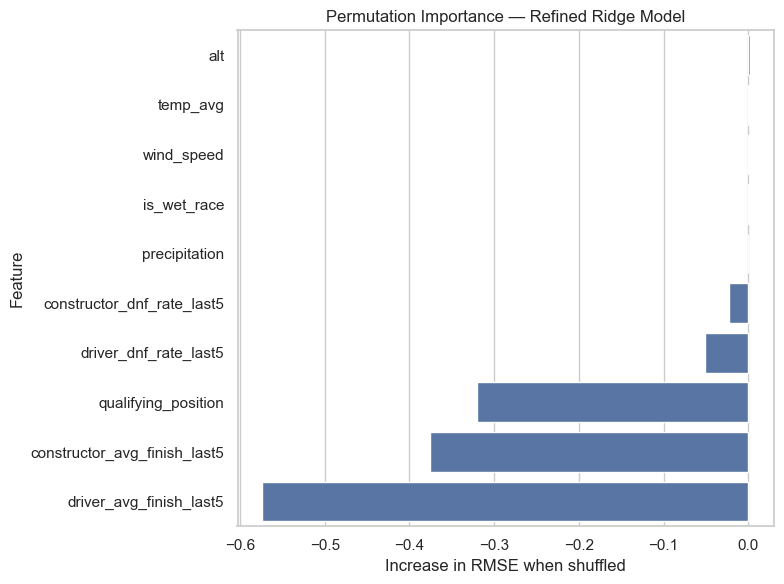

In [24]:
plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df, x="importance_mean", y="feature")
plt.title("Permutation Importance — Refined Ridge Model")
plt.xlabel("Increase in RMSE when shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importance Stability

Evaluate whether importance rankings remain consistent across bootstrap or rolling samples.

In [25]:
importance_rows = []

for seed in range(20):
    boot_idx = np.random.default_rng(seed).choice(len(X_train_refined), size=len(X_train_refined), replace=True)
    X_boot = X_train_refined.reset_index(drop=True).iloc[boot_idx]
    y_boot = y_train_refined.reset_index(drop=True).iloc[boot_idx]

    model = clone(ridge_pipeline_refined)
    model.fit(X_boot, y_boot)

    perm = permutation_importance(
        model,
        X_test_refined,
        y_test_refined,
        n_repeats=5,
        random_state=seed,
        scoring="neg_root_mean_squared_error"
    )

    for f, imp in zip(refined_features, -perm.importances_mean):
        importance_rows.append({
            "seed": seed,
            "feature": f,
            "importance": imp
        })

importance_stability = pd.DataFrame(importance_rows)
importance_stability.head()

,seed,feature,importance
0,0,qualifying_position,-0.348399
1,0,driver_avg_finish_last5,-0.538990
2,0,driver_dnf_rate_last5,-0.051957
3,0,constructor_avg_finish_last5,-0.328943
4,0,constructor_dnf_rate_last5,-0.016213


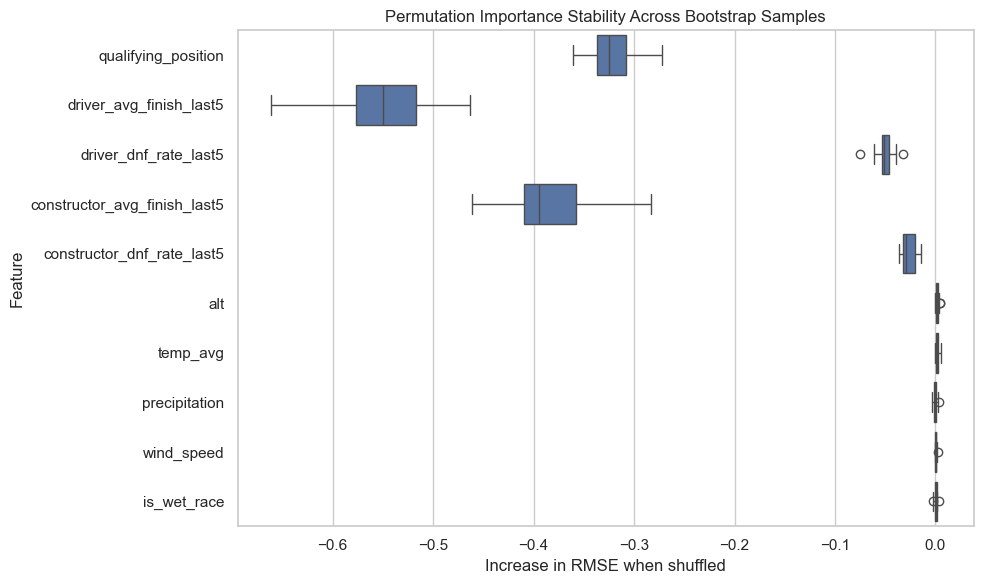

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=importance_stability, x="importance", y="feature")
plt.title("Permutation Importance Stability Across Bootstrap Samples")
plt.xlabel("Increase in RMSE when shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Compare Original vs Refined Dataset Quality

Evaluate whether feature refinement improves not just performance, but also consistency and interpretability.

In [28]:
comparison_df = baseline_results.merge(
    cv_results,
    on=["dataset", "model"],
    how="left"
)

comparison_df

,dataset,model,rmse,mae,r2,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,original,ridge,789.611215,473.651811,-18774.165963,6.409976,0.061077,5.287000,0.049955,0.300669,0.008743
1,refined,ridge,4.540352,3.622992,0.379222,6.538676,0.056880,5.386178,0.046717,0.272310,0.007687
2,original,xgboost,4.269074,3.336590,0.451187,5.900183,0.044098,4.807960,0.043041,0.407491,0.004534
3,refined,xgboost,4.297645,3.403110,0.443816,6.368013,0.048912,5.217653,0.042084,0.309820,0.003135


## Key Takeaways

- The refined feature set reduces redundancy and improves interpretability.
- Bootstrap confidence intervals help distinguish genuine performance differences from sampling noise.
- Cross-validation and rolling-origin validation show whether model quality is stable across resamples and time periods.
- Permutation importance reveals which features matter consistently, not just in a single train/test split.
- Final model selection should prioritize stability and robustness, not just best-case performance.